### 1) Load Saved Base Models and Scaler
Load the pretrained XGBoost model, Logistic Regression model, and fitted scaler from `models/` so calibration is applied to frozen trained models.


In [2]:
import sys, os
os.chdir(r'C:\Users\preet\Projects\major-project')
sys.path.insert(0, r'C:\Users\preet\Projects\major-project')
print("Working dir:", os.getcwd())
import joblib

xgb_model = joblib.load('models/xgboost_model.pkl')
lr_model = joblib.load('models/logistic_model.pkl')
scaler = joblib.load('models/scaler.pkl')

print('Loaded models and scaler from models/.')


Working dir: C:\Users\preet\Projects\major-project
Loaded models and scaler from models/.


### 2) Load Calibration Split
Load `X_calib` and `y_calib` from processed artifacts. This split is used only for calibration-related fitting and evaluation.


In [3]:
import pandas as pd

X_cal = pd.read_csv('data/processed/X_calib.csv')
y_cal = pd.read_csv('data/processed/y_calib.csv').iloc[:, 0]

print('Calibration set shapes:', X_cal.shape, y_cal.shape)


Calibration set shapes: (732, 7) (732,)


### 3) Apply Platt Scaling and Measure Brier Improvement
Create a Platt-calibrated XGBoost model and compute Brier score before and after calibration.


In [4]:
from src.uncertainty.calibration import calibrate_platt, compute_brier_score

brier_before = compute_brier_score(xgb_model, X_cal, y_cal)
platt_model = calibrate_platt(xgb_model, X_cal, y_cal)
brier_platt = compute_brier_score(platt_model, X_cal, y_cal)

print('Brier before calibration:', brier_before)
print('Brier after Platt calibration:', brier_platt)


Brier before calibration: 0.1180344969034195
Brier after Platt calibration: 0.09572725285202176


### 4) Apply Isotonic Regression and Measure Brier Score
Create an Isotonic-calibrated XGBoost model and compute its calibration-set Brier score.


In [5]:
from src.uncertainty.calibration import calibrate_isotonic

isotonic_model = calibrate_isotonic(xgb_model, X_cal, y_cal)
brier_isotonic = compute_brier_score(isotonic_model, X_cal, y_cal)

print('Brier after Isotonic calibration:', brier_isotonic)


Brier after Isotonic calibration: 0.09181631847526499


### 5) Plot Reliability Curves for Four Models
Plot and save calibration curves for uncalibrated XGBoost, Platt-calibrated XGBoost, Isotonic-calibrated XGBoost, and Logistic Regression in one figure.


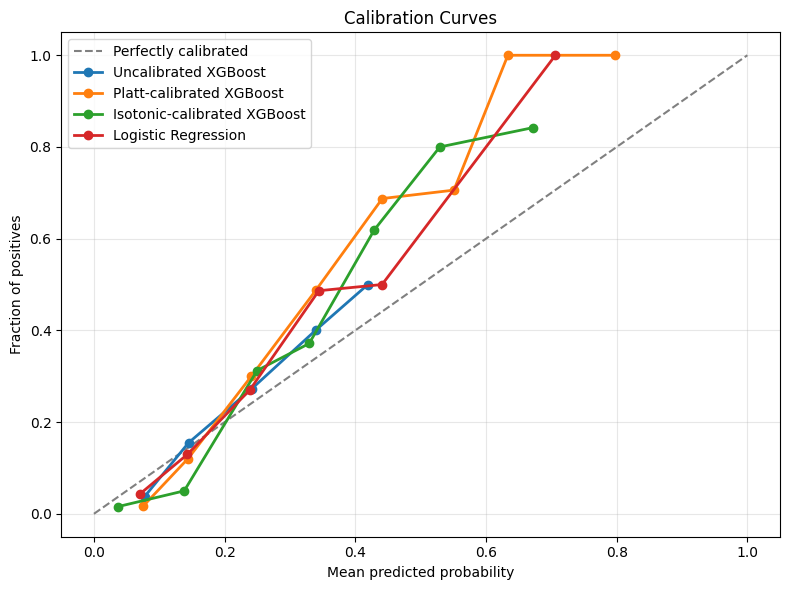

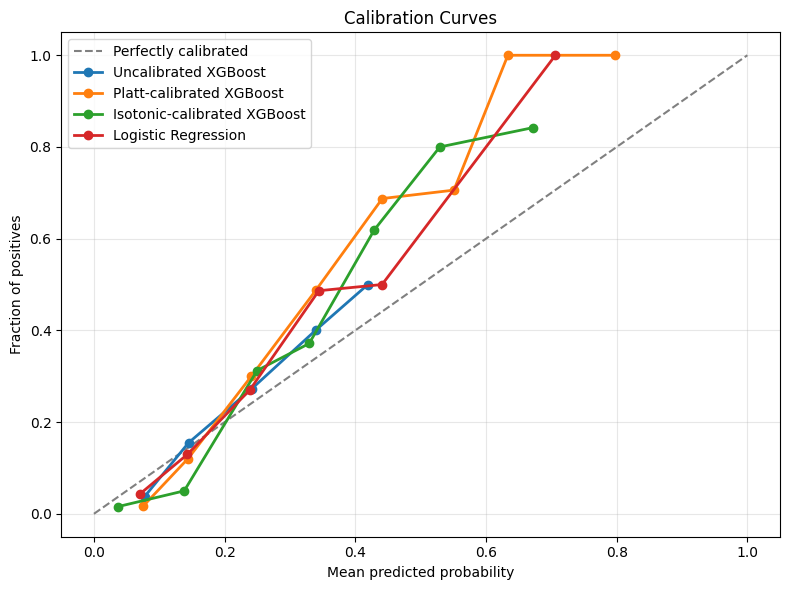

In [6]:
from src.uncertainty.calibration import plot_calibration_curve

models_dict = {
    'Uncalibrated XGBoost': xgb_model,
    'Platt-calibrated XGBoost': platt_model,
    'Isotonic-calibrated XGBoost': isotonic_model,
    'Logistic Regression': lr_model,
}

fig = plot_calibration_curve(
    models_dict=models_dict,
    X=X_cal,
    y=y_cal,
    save_path='artifacts/plots/calibration_curve.png',
)
fig


### 6) Select Best Calibrator by Brier Score
Choose the calibrator with lower calibration-set Brier score and print both scores with the selected winner.


In [7]:
from src.uncertainty.calibration import select_best_calibrator

best_calibrator, winner, platt_brier, isotonic_brier = select_best_calibrator(
    platt_model, isotonic_model, X_cal, y_cal
)

print('Selected calibrator:', winner)
print('Platt Brier:', platt_brier)
print('Isotonic Brier:', isotonic_brier)


Selected calibrator: isotonic
Platt Brier: 0.09572725285202176
Isotonic Brier: 0.09181631847526499


### 7) Save Selected Calibrator
Persist the selected calibrated model to `models/calibrator.pkl` for downstream uncertainty and inference workflows.


In [8]:
joblib.dump(best_calibrator, 'models/calibrator.pkl')
print('Saved calibrated model to models/calibrator.pkl')


Saved calibrated model to models/calibrator.pkl


### 8) Log Calibration Metrics and Plot to Weights & Biases
Log Brier scores including required improvement fields and upload the calibration curve image as a W&B artifact.


In [9]:
from src.utils.wandb_logger import init_run, log_metrics, log_artifact, finish_run

run = init_run(
    run_name='calibration_evaluation',
    config_dict={
        'random_seed': 42,
        'dataset_name': 'framingham',
        'split_sizes': {'train': 0.60, 'calibration': 0.20, 'holdout': 0.20},
        'model_type': 'xgboost_calibration',
    },
)

try:
    brier_after = min(brier_platt, brier_isotonic)
    log_metrics({
        'brier_before_calibration': brier_before,
        'brier_after_calibration': brier_after,
        'brier_platt': brier_platt,
        'brier_isotonic': brier_isotonic,
    })
    log_artifact(
        file_path='artifacts/plots/calibration_curve.png',
        artifact_type='plot',
        artifact_name='calibration_curve',
    )
finally:
    finish_run()

print('Logged calibration metrics and curve to W&B.')


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\preet\_netrc.
wandb: Currently logged in as: spamyuvraj555 (spamyuvraj555-federal-student-aid) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


brier_after_calibration,▁
brier_before_calibration,▁
brier_isotonic,▁
brier_platt,▁
brier_after_calibration,0.09182
brier_before_calibration,0.11803
brier_isotonic,0.09182
brier_platt,0.09573


Logged calibration metrics and curve to W&B.
